# Modélisation du bruit de la chaîne ADC

In [1]:
import numpy as np
from scipy import constants


### Fonctions ###
def Celsius2Kelvin(TC):
    TK = TC + constants.zero_Celsius
    return TK


def thermal_noise(R, TK):
    en = np.sqrt(4 * constants.Boltzmann * R * TK)
    return en


def shot_noise(I):
    inn = np.sqrt(2 * constants.elementary_charge * I)
    return inn


def quantization_noise(Vpp, N, Fs):
    LSB = Vpp / 2 ** N
    RMS_q = LSB / np.sqrt(12)
    e_q = RMS_q / np.sqrt(Fs / 2)
    return e_q, RMS_q, LSB


def export_2vectors_to_file(x, y, filename):
    if len(x) != len(y):
        raise ValueError("The vectors have different sizes")
    with open(filename, 'w') as file:
        for i in range(len(x)):
            file.write('{0:}  {1:}\n'.format(x[i], y[i]))

## Bruit produit par les différents éléments
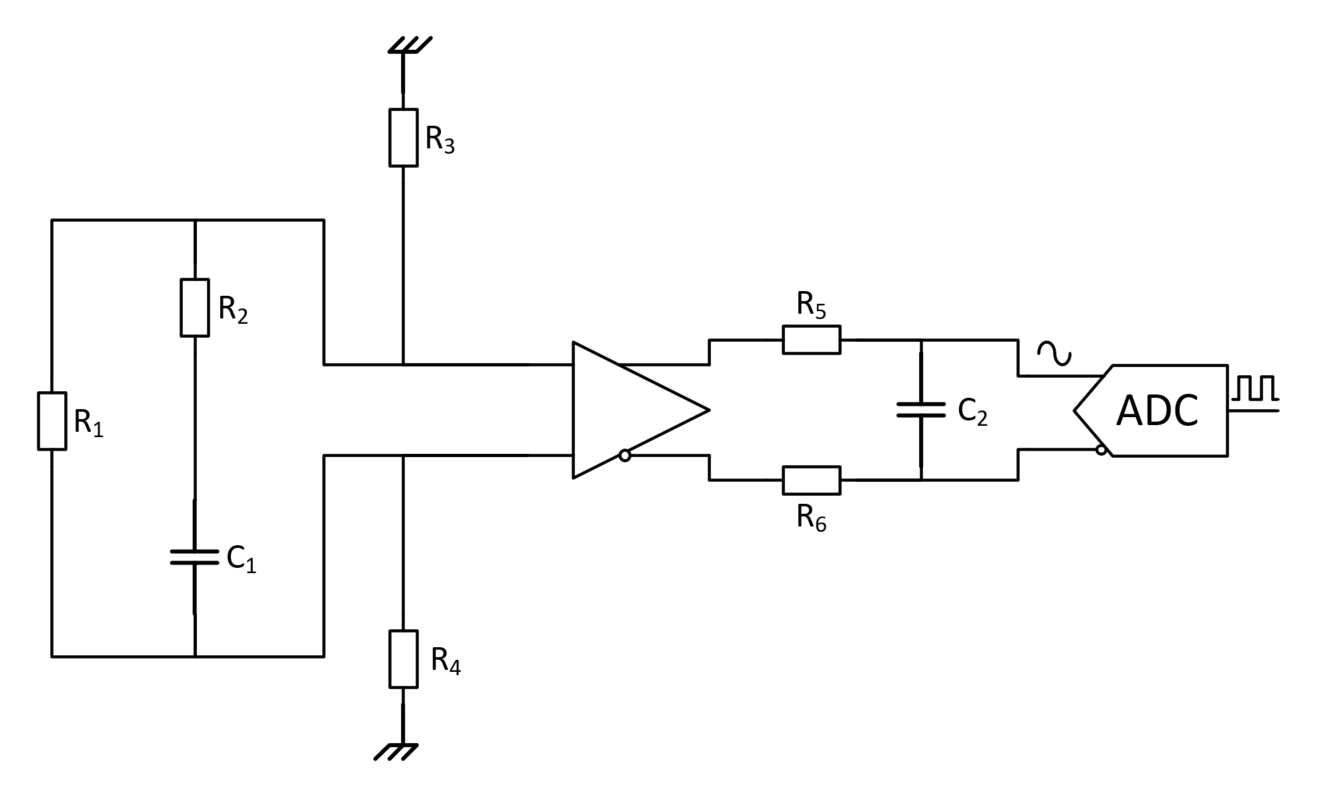


In [2]:
#Température
T = 25  #°C

### Résistances ###
R1 = 100
R2 = 100
R3 = 10e3
R4 = 10e3
R5 = 15
R6 = 15

er1 = thermal_noise(R1, Celsius2Kelvin(T))
er2 = thermal_noise(R2, Celsius2Kelvin(T))
er3 = thermal_noise(R3, Celsius2Kelvin(T))
er4 = thermal_noise(R4, Celsius2Kelvin(T))
er5 = thermal_noise(R5, Celsius2Kelvin(T))
er6 = thermal_noise(R6, Celsius2Kelvin(T))

### Actifs ###
#RHF200
e_rhf_o = 10e-9
#ADC
Fs, data_filename = 125e6, 'erro-only_125.txt'
#Fs, data_filename = 6.25e6, 'erro-only_6p25.txt'
Vpp = 2
N = 14
#quantization noise
e_adc_q, _, LSB = quantization_noise(Vpp, N, Fs)
#thermal noise
rms_adc_th = 1.25  #LSB rms
BW_adc_th_noise = 150e6 / 2  #Hz
#Input BW
ADC_BW = 650e6
tau_c_ADC = 1 / (2 * np.pi * ADC_BW)
H_ADC = lambda w: 1 / (1 + 1j * tau_c_ADC * w)
#Calcul de la densité spectrale de bruit thermique
e_adc_th_Ny = rms_adc_th * LSB / np.sqrt(BW_adc_th_noise)  #etalage sur Nyquist
Beq_th = np.pi / 2 * ADC_BW
e_adc_th = e_adc_th_Ny * np.sqrt(BW_adc_th_noise / Beq_th)  #étalage sur toute la bande vis à vis repliement

# Gain des différents bruits

In [3]:
### Gain du LNA ###
gain_rhf = 1

### Capacités de filtrage ###
C1 = 15e-12
C2 = 270e-12

### Les gains permettent de ramener les bruits en entrée de l'ADC ###

#Gain de R5 ou R6
H_R56 = lambda w: 1 / (1 + 1j * (R5 + R6) * C2 * w) * H_ADC(w)

# Gain de R1
zequi_1 = lambda w: (R3 + R4) * (1 + 1j * R2 * C1 * w) / (
        1 + 1j * C1 * (R2 + R3 + R4) * w)  # impédance équivalente vue après R1
H_R1 = lambda w: zequi_1(w) / (R1 + zequi_1(w)) * gain_rhf * H_R56(w)

# Gain de R2
zequi_2 = 1 / (1 / R1 + 1 / (R3 + R4))
H_R2 = lambda w: 1j * zequi_2 * C1 * w / (1 + 1j * (zequi_2 + R2) * C1 * w) * gain_rhf * H_R56(w)

# Gain de R3 ou R4
zequi_3 = lambda w: R1 * (1 + 1j * R2 * C1 * w) / (1 + 1j * C1 * (R2 + R1) * w)
H_R34 = lambda w: 1 / (1 + (R3 + R4) / zequi_3(w)) * gain_rhf * H_R56(w)

#Gain RHF200
H_rhf = lambda w: gain_rhf * H_R56(w)

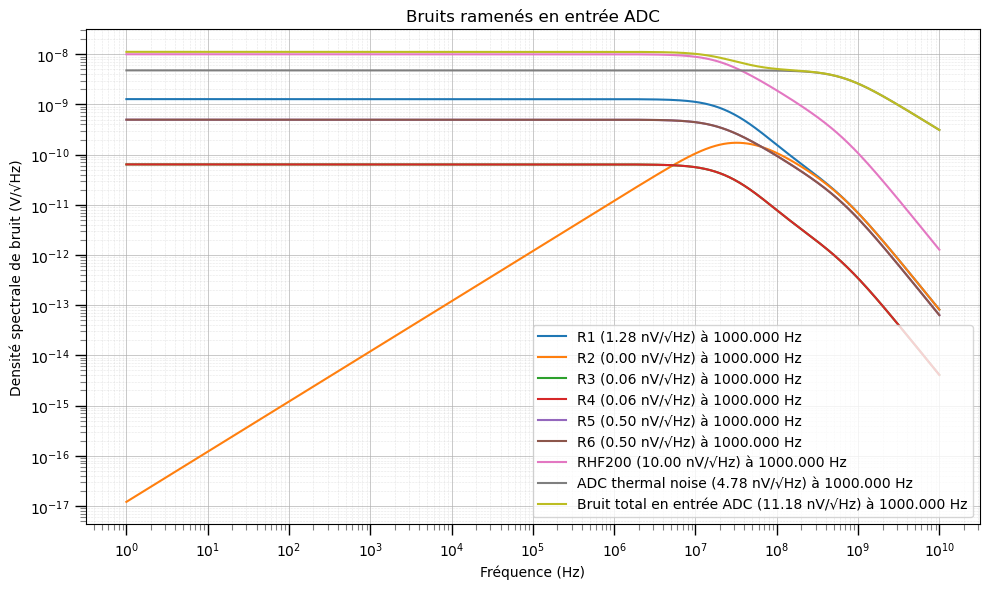

In [4]:
##### test fonctions de transfert ####
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(0, 10, 1000)  # 1 Hz à 10 GHz
w = 2 * np.pi * f

#Vecteurs des bruits ramenés en entrée ADC
er1_out = lambda w: np.abs(H_R1(w)) * er1
er2_out = lambda w: np.abs(H_R2(w)) * er2
er3_out = lambda w: np.abs(H_R34(w)) * er3
er4_out = lambda w: np.abs(H_R34(w)) * er4
er5_out = lambda w: np.abs(H_R56(w)) * er5
er6_out = lambda w: np.abs(H_R56(w)) * er6
erhf_out = lambda w: np.abs(H_rhf(w)) * e_rhf_o
#e_adc_th_out = lambda w: e_adc_th * (np.array(w) <= (np.pi * 2 * BW_adc_th_noise))
e_adc_th_out = lambda w: np.abs(H_ADC(w)) * e_adc_th

e_total_in_adc = lambda w: np.sqrt(
    er1_out(w) ** 2 + er2_out(w) ** 2 + er3_out(w) ** 2 + er4_out(w) ** 2 + er5_out(w) ** 2 + er6_out(
        w) ** 2 + erhf_out(w) ** 2 + e_adc_th_out(w) ** 2)
#e_total_in_adc = lambda w: np.sqrt(er1_out(w)**2+er2_out(w)**2+er3_out(w)**2+er4_out(w)**2+er5_out(w)**2+er6_out(w)**2+erhf_out(w)**2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, er1_out(w), label=f"R1 ({er1_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er2_out(w), label=f"R2 ({er2_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er3_out(w), label=f"R3 ({er3_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er4_out(w), label=f"R4 ({er4_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er5_out(w), label=f"R5 ({er5_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er6_out(w), label=f"R6 ({er6_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, erhf_out(w), label=f"RHF200 ({erhf_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_adc_th_out(w),
          label=f"ADC thermal noise ({e_adc_th_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

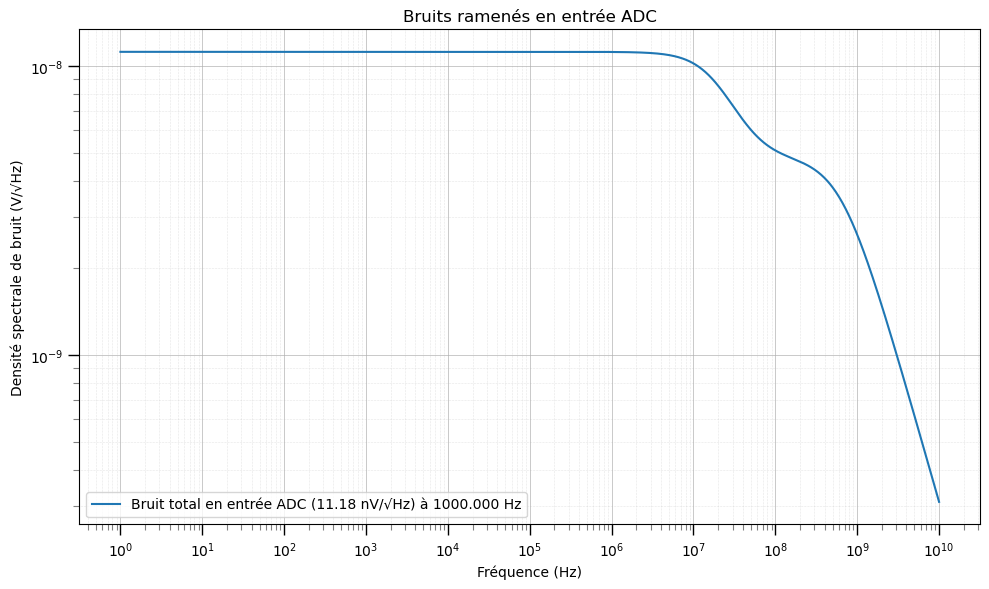

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

In [6]:
### Bruit replié par échantillonage ###

# ==== PARAMÈTRES ====
fmax = 100e9  # domaine fréquentiel du système analogique (Hz)
N_num = 200  # nombre de points en numérique sur Fs/2
f_nyq = Fs / 2  #fréquence de nyquist

#freqs numériques
f_num = np.unique(np.round(np.logspace(0, np.ceil(np.log10(f_nyq)), N_num)))  #arrondi au Hz et unique
f_num = f_num[f_num < f_nyq]
f_num = np.append(f_num, f_nyq)  #on est sûr de pas dépasser la fréquence de nyquist et d'avoir un point dessus
#on ajoute les repliement "impaire" Fs-f
f_num = np.unique(np.sort(np.append(f_num, Fs - f_num)))

# Fréquence analogique (Hz)
# ce sont les fréquences numériques périodisée sur toute la bande
k_alias_max = np.ceil(fmax / Fs)

# Construction des alias
k_alias = np.arange(0, k_alias_max + 1)[:, None]  # vecteur colonne
f_analogique = f_num + k_alias * Fs  # ajoute tous les multiples de Fs
f_analogique = f_analogique[(f_analogique <= fmax)]  # ne garde que les fréquences inférieure

# Tri final
f_analogique = np.unique(np.sort(f_analogique))  #on s'assure de l'unicité (cas où on a une freq à 0 et Fs par exemple)

# ==== CALCUL ====

#repliement fréquentiel
f_modulo = np.mod(f_analogique, Fs)
f_repliee = np.where(f_modulo > f_nyq, Fs - f_modulo, f_modulo)

#indices des fréquences identiques
indices = np.searchsorted(f_num, f_repliee)

# Somme des contributions
e_total_out_adc_square = np.zeros_like(f_analogique)
e_vect_in = e_total_in_adc(2 * np.pi * f_analogique)
#e_vect_in = np.ones_like(f_analogique)*1e-9 cas de test
np.add.at(e_total_out_adc_square, indices, e_vect_in ** 2)

# On prend la NSD mais que jusqu'à Fnyq
ind_nyq = np.where(f_analogique == f_nyq)[0][0]  ## existe vu la définition de f_analogique
f_num = f_analogique[:ind_nyq]
e_total_out_adc = np.sqrt(e_total_out_adc_square[:ind_nyq])


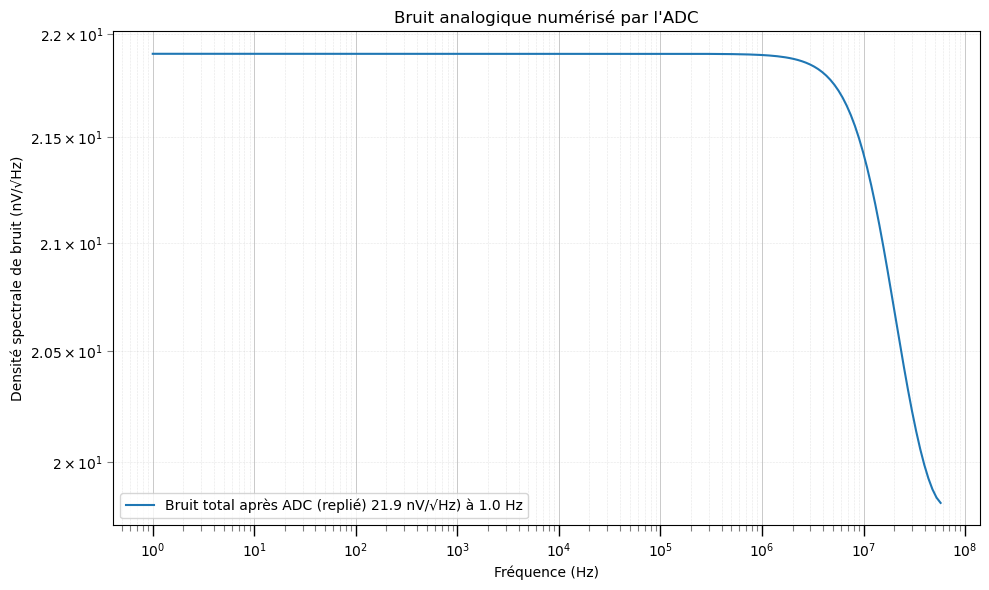

In [7]:
# ==== AFFICHAGE ====
N_print = 0
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_total_out_adc * 1e9,
          label=f"Bruit total après ADC (replié) {e_total_out_adc[N_print] * 1e9:.1f} nV/√Hz) à {freq_print:.1f} Hz")
#ax.loglog(f_num, np.ones_like(f_num),label=f"Bruit avant repliement {1}")

### Mise en forme ###
ax.set_title("Bruit analogique numérisé par l'ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()


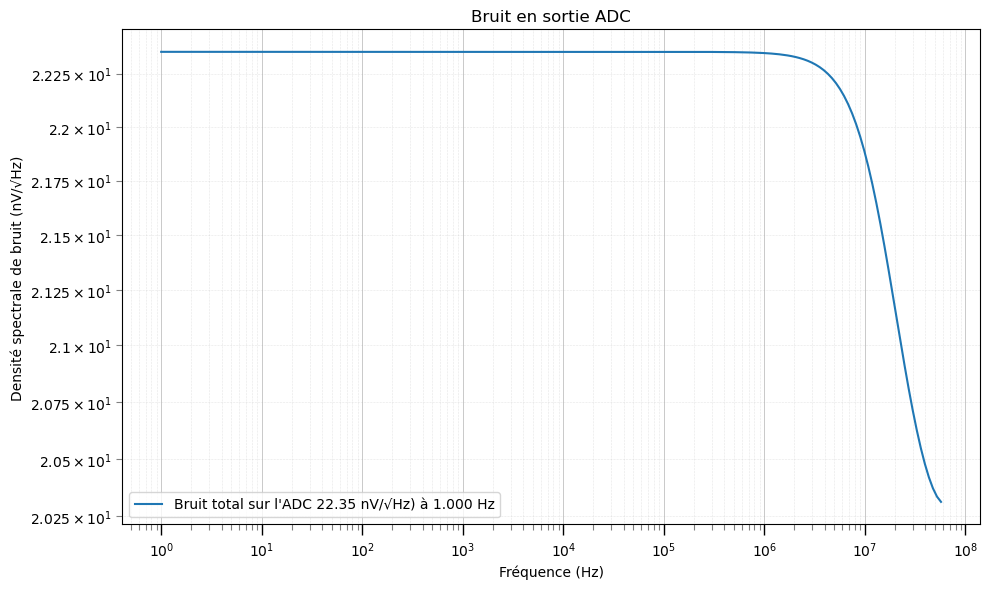

In [8]:
# ajout des bruits internes de l'ADC (thermique et quantification)
#e_th_adc_fs = rms_adc_th*LSB/np.sqrt(f_nyq)
#e_th_adc_fs = e_adc_th

#print(f'Bruit thermique de l\'ADC ramené à son entrée: {e_th_adc_fs*1e9:.3f} nV/√Hz')

#e_total = np.sqrt(np.ones_like(f_num)*(e_th_adc_fs**2) + np.ones_like(f_num)*e_adc_q**2 + e_total_out_adc**2)
e_total = np.sqrt(np.ones_like(f_num) * e_adc_q ** 2 + e_total_out_adc ** 2)

# ==== AFFICHAGE ====
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_total * 1e9, label=f"Bruit total sur l'ADC {e_total[1] * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruit en sortie ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()


In [9]:
print(f'RMS bruit thermique ADC {e_total_out_adc[1] * np.sqrt(Fs / 2) / LSB}')

RMS bruit thermique ADC 1.4186259979270477


In [10]:
export_2vectors_to_file(f_num, e_total, data_filename)